In [ ]:
pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 23.3 MB/s eta 0:00:00


In [ ]:
pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 42.6 MB/s eta 0:00:00


In [ ]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

from albumentations import Compose, Resize, HorizontalFlip, RandomBrightnessContrast, GaussNoise
from albumentations.pytorch import ToTensorV2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import efficientnet_b0
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import models
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from collections import Counter
from torchmetrics import Accuracy, Precision, Recall, F1Score
from torchmetrics.classification import BinaryAccuracy, BinaryPrecision, BinaryRecall, BinaryF1Score

from ultralytics import YOLO

import warnings
warnings.filterwarnings('ignore')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Classes: ['non shop lifters', 'shop lifters']
{'non shop lifters': 630, 'shop lifters': 430}


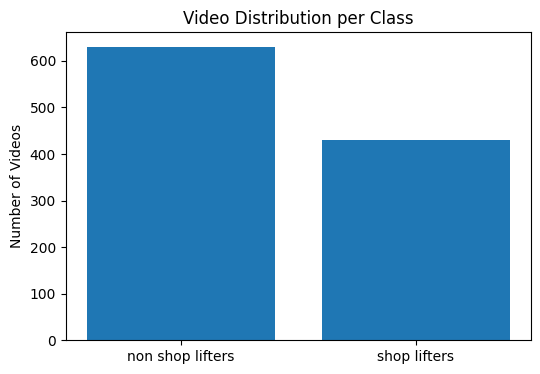

In [ ]:
data_root = "/content/drive/MyDrive/shoplifting/Shop DataSet"

classes = sorted([d for d in os.listdir(data_root) if os.path.isdir(os.path.join(data_root, d))])
print("Classes:", classes)

# Class distribution
def count_videos_per_class(root):
    counter = {}
    for cls in classes:
        cls_path = os.path.join(root, cls)
        vids = [f for f in os.listdir(cls_path) if f.lower().endswith(('.mp4', '.avi'))]
        counter[cls] = len(vids)
    return counter

# Visualization
def visualize_class_dist(counter):
    plt.figure(figsize=(6,4))
    plt.bar(counter.keys(), counter.values())
    plt.ylabel('Number of Videos')
    plt.title('Video Distribution per Class')
    plt.show()

count = count_videos_per_class(data_root)
print(count)
visualize_class_dist(count)

In [ ]:
class VideoDataset(Dataset):
    def __init__(self, video_paths, labels, num_frames=16, size=(224, 224)):
        self.video_paths = video_paths
        self.labels = labels
        self.num_frames = num_frames
        self.size = size

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        path = self.video_paths[idx]
        label = torch.tensor(self.labels[idx], dtype=torch.float32)

        cap = cv2.VideoCapture(path)
        frames = []

        if not cap.isOpened():
            # resample instead of crashing
            return self.__getitem__((idx + 1) % len(self.video_paths))

        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, self.size)
            frames.append(frame)

        cap.release()

        # 🔴 CRITICAL SAFETY CHECK
        if len(frames) == 0:
            return self.__getitem__((idx + 1) % len(self.video_paths))

        total = len(frames)

        if total >= self.num_frames:
            indices = np.linspace(0, total - 1, self.num_frames, dtype=int)
            frames = [frames[i] for i in indices]
        else:
            frames += [frames[-1]] * (self.num_frames - total)

        frames = np.array(frames, dtype=np.float32) / 255.0
        frames = torch.from_numpy(frames).permute(0, 3, 1, 2)  # (T, C, H, W)

        return frames, label


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data, labels = [], []
for label, cls in enumerate(classes):
    folder = os.path.join(data_root, cls)
    for file in os.listdir(folder):
        if file.lower().endswith('.mp4'):
            data.append(os.path.join(folder, file))
            labels.append(label)

num_frames = 16
img_size = (224, 224)
batch_size = 8

# Split
train_paths, test_paths, y_train, y_test = train_test_split(data, labels, test_size=0.3, stratify=labels, random_state=42)
val_paths, test_paths, y_val, y_test = train_test_split(test_paths, y_test, test_size=0.5, stratify=y_test, random_state=42)

# Datasets
train_dataset = VideoDataset(train_paths, y_train, num_frames, img_size)
val_dataset = VideoDataset(val_paths, y_val, num_frames, img_size)
test_dataset = VideoDataset(test_paths, y_test, num_frames, img_size)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

In [ ]:
class EfficientNet_Transformer(nn.Module):
    def __init__(self, num_classes=1, d_model=1280, nhead=8):
        super().__init__()
        backbone = efficientnet_b0(pretrained=True)
        backbone.classifier = nn.Identity()
        self.backbone = backbone

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        b, t, c, h, w = x.shape
        x = x.view(b*t, c, h, w)

        feats = self.backbone(x)        # (b*t, 1280)
        feats = feats.view(b, t, -1)

        out = self.transformer(feats)
        out = out.mean(dim=1)

        return torch.sigmoid(self.fc(out))








In [ ]:
def train_model(epochs=5):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    model = EfficientNet_Transformer().to(device)
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
    f1_metric = BinaryF1Score().to(device)
    acc_metric = BinaryAccuracy().to(device)

    # Store metrics
    history = {k: [] for k in ['train_loss','val_loss','train_accuracy','val_accuracy','train_f1','val_f1']}

    # Early stopping parameters
    patience = 5
    best_val_loss = float('inf')
    no_improve_epochs = 0

    for epoch in range(epochs):
        # Train
        model.train()
        total_loss, total_f1, total_acc = 0, 0, 0
        for videos, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            videos, labels = videos.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(videos).squeeze(1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            preds = (outputs > 0.5).int()
            total_loss += loss.item()
            total_f1 += f1_metric(preds, labels.int()).item()
            total_acc += acc_metric(preds, labels.int()).item()

        avg_loss = total_loss / len(train_loader)
        avg_f1 = total_f1 / len(train_loader)
        avg_acc = total_acc / len(train_loader)

        history['train_loss'].append(avg_loss)
        history['train_accuracy'].append(avg_acc)
        history['train_f1'].append(avg_f1)

        # Validation
        model.eval()
        val_loss, val_f1, val_acc = 0, 0, 0
        with torch.no_grad():
            for videos, labels in val_loader:
                videos, labels = videos.to(device), labels.to(device)
                outputs = model(videos).squeeze(1)
                loss = criterion(outputs, labels)

                preds = (outputs > 0.5).int()
                val_loss += loss.item()
                val_f1 += f1_metric(preds, labels.int()).item()
                val_acc += acc_metric(preds, labels.int()).item()

        avg_val_loss = val_loss / len(val_loader)
        avg_val_f1 = val_f1 / len(val_loader)
        avg_val_acc = val_acc / len(val_loader)

        history['val_loss'].append(avg_val_loss)
        history['val_accuracy'].append(avg_val_acc)
        history['val_f1'].append(avg_val_f1)

        print(f'Epoch {epoch+1} -> Loss: {avg_loss:.4f}, Val Loss: {avg_val_loss:.4f} | F1: {avg_f1:.4f}, Val F1: {avg_val_f1:.4f} | Acc: {avg_acc:.4f}, Val Acc: {avg_val_acc:.4f}')

        # Update learning rate
        scheduler.step(avg_val_loss)
        print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")

        # Check For Early Stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            no_improve_epochs = 0
            torch.save(model.state_dict(), 'best_model.pth')
            print('Model improved — saved')
        else:
            no_improve_epochs += 1
            print(f'No improvement for {no_improve_epochs} epoch(s)')

        if no_improve_epochs >= patience:
            print('Early stopping triggered')
            break

    model.load_state_dict(torch.load('best_model.pth'))
    return model, history

model, history = train_model(epochs=15)

Epoch 1: 100%|██████████| 93/93 [05:52<00:00,  3.80s/it]


Epoch 1 -> Loss: 0.4008, Val Loss: 0.1220 | F1: 0.7501, Val F1: 0.8803 | Acc: 0.8141, Val Acc: 0.9375
Learning Rate: 0.000100
Model improved — saved


Epoch 2: 100%|██████████| 93/93 [06:01<00:00,  3.89s/it]


Epoch 2 -> Loss: 0.1614, Val Loss: 0.0766 | F1: 0.8980, Val F1: 0.9172 | Acc: 0.9341, Val Acc: 0.9563
Learning Rate: 0.000100
Model improved — saved


Epoch 3: 100%|██████████| 93/93 [05:53<00:00,  3.80s/it]


...

Epoch 5 -> Loss: 0.1049, Val Loss: 0.1237 | F1: 0.9464, Val F1: 0.8558 | Acc: 0.9556, Val Acc: 0.9563
Learning Rate: 0.000100
No improvement for 3 epoch(s)


Epoch 6: 100%|██████████| 93/93 [05:52<00:00,  3.79s/it]


Epoch 6 -> Loss: 0.0692, Val Loss: 0.1307 | F1: 0.9318, Val F1: 0.8674 | Acc: 0.9700, Val Acc: 0.9500
Learning Rate: 0.000010
No improvement for 4 epoch(s)


Epoch 7: 100%|██████████| 93/93 [05:53<00:00,  3.80s/it]


Epoch 7 -> Loss: 0.0549, Val Loss: 0.1358 | F1: 0.9580, Val F1: 0.8550 | Acc: 0.9807, Val Acc: 0.9500
Learning Rate: 0.000010
No improvement for 5 epoch(s)
Early stopping triggered


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
criterion = nn.BCELoss()

from torchmetrics.classification import (
    BinaryAccuracy, BinaryPrecision, BinaryRecall, BinaryF1Score
)

acc_metric = BinaryAccuracy().to(device)
precision_metric = BinaryPrecision().to(device)
recall_metric = BinaryRecall().to(device)
f1_metric = BinaryF1Score().to(device)

# Evaluation function
def evaluate(model, loader, name="Eval"):
    model.eval()
    total_loss, total_f1, total_acc, total_prec, total_rec = 0, 0, 0, 0, 0

    with torch.no_grad():
        for videos, labels in loader:
            videos, labels = videos.to(device), labels.to(device)

            outputs = model(videos).squeeze(1)
            loss = criterion(outputs, labels)

            preds = (outputs > 0.5).int()

            total_loss += loss.item()
            total_f1 += f1_metric(preds, labels.int()).item()
            total_acc += acc_metric(preds, labels.int()).item()
            total_prec += precision_metric(preds, labels.int()).item()
            total_rec += recall_metric(preds, labels.int()).item()

    n = len(loader)
    print(f'Loss: {total_loss/n:.4f} | '
          f'F1: {total_f1/n:.4f} | Acc: {total_acc/n:.4f} | '
          f'Prec: {total_prec/n:.4f} | Rec: {total_rec/n:.4f}')

# Evaluate
print('Training Results:')
evaluate(model, train_loader, "Train")

print("\nValidation Results:")
evaluate(model, val_loader, "Validation")

print("\nTest Results:")
evaluate(model, test_loader, "Test")

Training Results:
Loss: 0.0638 | F1: 0.9610 | Acc: 0.9718 | Prec: 0.9423 | Rec: 0.9946

Validation Results:
Loss: 0.0766 | F1: 0.9172 | Acc: 0.9563 | Prec: 0.9092 | Rec: 0.9300

Test Results:
Loss: 0.0909 | F1: 0.9601 | Acc: 0.9625 | Prec: 0.9383 | Rec: 0.9917


In [ ]:
def plot_training_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(15, 5))

    # Loss plot
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss', color='b')
    plt.plot(epochs, history['val_loss'], label='Val Loss', color='m')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss")

    # Accuracy plot
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history['train_accuracy'], label='Train Accuracy', color='b')
    plt.plot(epochs, history['val_accuracy'], label='Val Accuracy', color='m')
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Accuracy")

    # F1 Score plot
    plt.subplot(1, 3, 3)
    plt.plot(epochs, history['train_f1'], label='Train F1', color='b')
    plt.plot(epochs, history['val_f1'], label='Val F1', color='m')
    plt.xlabel("Epochs")
    plt.ylabel("F1 Score")
    plt.legend()
    plt.title("F1 Score")

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_confusion_matrix(model, dataloader, class_names, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            videos, labels = batch
            videos, labels = videos.float().to(device), labels.to(device)
            outputs = model(videos)

            preds = (outputs.squeeze(1) > 0.5).int()  # Binary threshold
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Compute confusion matrix & F1
    cm = confusion_matrix(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, pos_label=1)

    # Plot heatmap
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix (F1 Score: {f1:.4f})')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

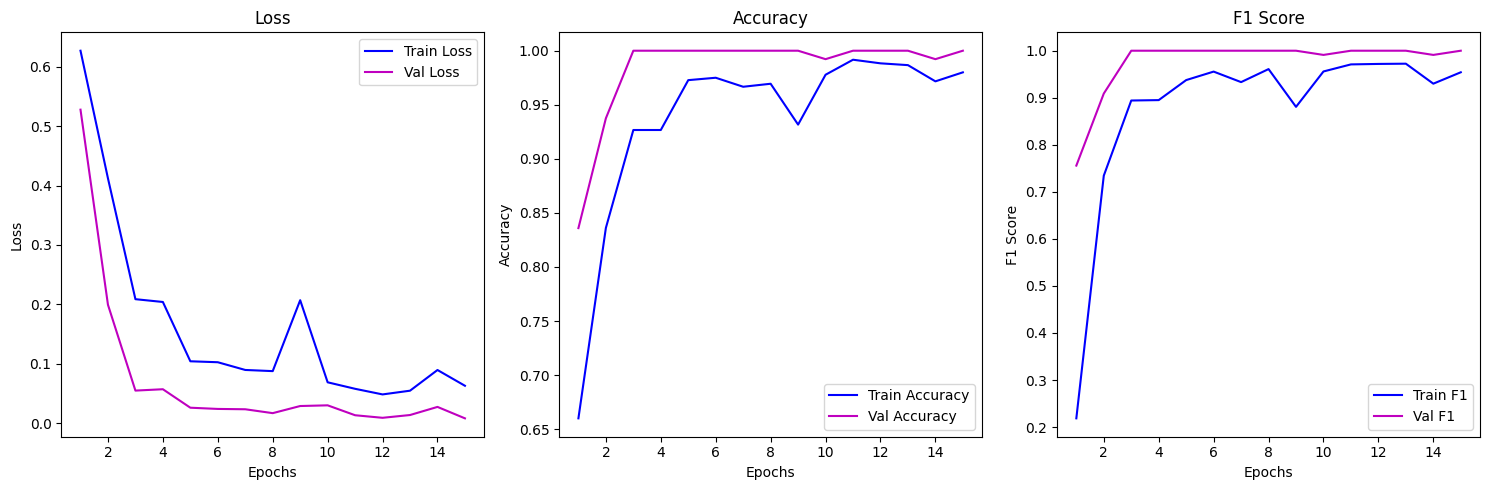

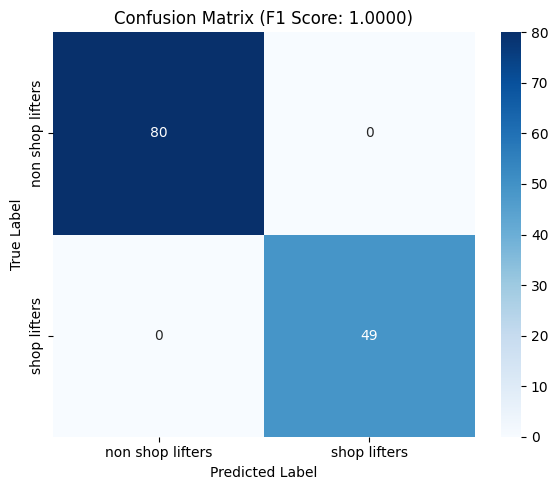

In [ ]:
plot_training_history(history)
plot_confusion_matrix(model, test_loader, classes, device)

Predict whether a given video is a shoplifting or non-shoplifting instance.

In [ ]:
def predict_video(model, video_path, device, threshold=0.5, transform=None):
    model.eval()

    cap = cv2.VideoCapture(video_path)
    frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        if transform:
            frame_tensor = transform(frame_rgb)
        else:
            # Default preprocessing (match training)
            frame_resized = cv2.resize(frame_rgb, (224, 224))
            frame_tensor = torch.tensor(frame_resized).permute(2, 0, 1).float() / 255.0
        frames.append(frame_tensor)
    cap.release()

    if len(frames) == 0:
        raise ValueError("No frames found in video.")

    # Stack into shape (1, T, C, H, W)
    video_tensor = torch.stack(frames).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(video_tensor).squeeze(1)
        prob = torch.sigmoid(outputs).item()

    predicted_class = "Shoplifter" if prob > threshold else "Non Shoplifter"
    return predicted_class, prob

In [ ]:
def visualize_frames(vid='/kaggle/input/shop-dataset/Shop DataSet/shop lifters/shop_lifter_0.mp4'):
    # Load YOLO pretrained model
    yolo_model = YOLO('yolov8n.pt')  # Pretrained on COCO

    # Open input video
    cap = cv2.VideoCapture(vid)

    # Video properties
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # Output video writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter('output.mp4', fourcc, fps, (width, height))

    frames_to_show = []
    frame_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Run YOLO person detection (no labels)
        results = yolo_model.predict(frame, classes=[0], verbose=False)  # class 0 = person

        # Draw green boxes without labels
        for box in results[0].boxes.xyxy:  # xyxy format
            x1, y1, x2, y2 = map(int, box)
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), thickness=2)  # Green box

        out.write(frame)

        # Store every 30th frame for display
        if frame_count % 30 == 0:
            frames_to_show.append(frame.copy())

        frame_count += 1

    cap.release()
    out.release()

    print("Video saved as 'output.mp4'")

    while len(frames_to_show) < 10:
        frames_to_show.append(np.zeros_like(frames_to_show[0]))

    # Display frames in 2x8 grid
    fig, axes = plt.subplots(2, 5, figsize=(20, 10))
    for i, ax in enumerate(axes.flat):
        ax.imshow(cv2.cvtColor(frames_to_show[i], cv2.COLOR_BGR2RGB))
        ax.axis("off")
    plt.tight_layout()
    plt.show()

In [ ]:
model == torch.load('best_model.pth')

False

In [ ]:
label, prob = predict_video(model, '/content/shoplifting_Shoplifting_Tag_Team_Caught_Stealing_Crackers_Nutty_Buddies.mp4', device)
print(f'Prediction: {label} (Confidence level: {prob:.4f})')

ValueError: No frames found in video.

Prediction for "shoplifting_Shoplifting_Tag_Team_Caught_Stealing_Crackers_Nutty_Buddies.mp4":
	Predicted Class: Shoplifter (Confidence: 0.6123)
Video saved as 'output.mp4'


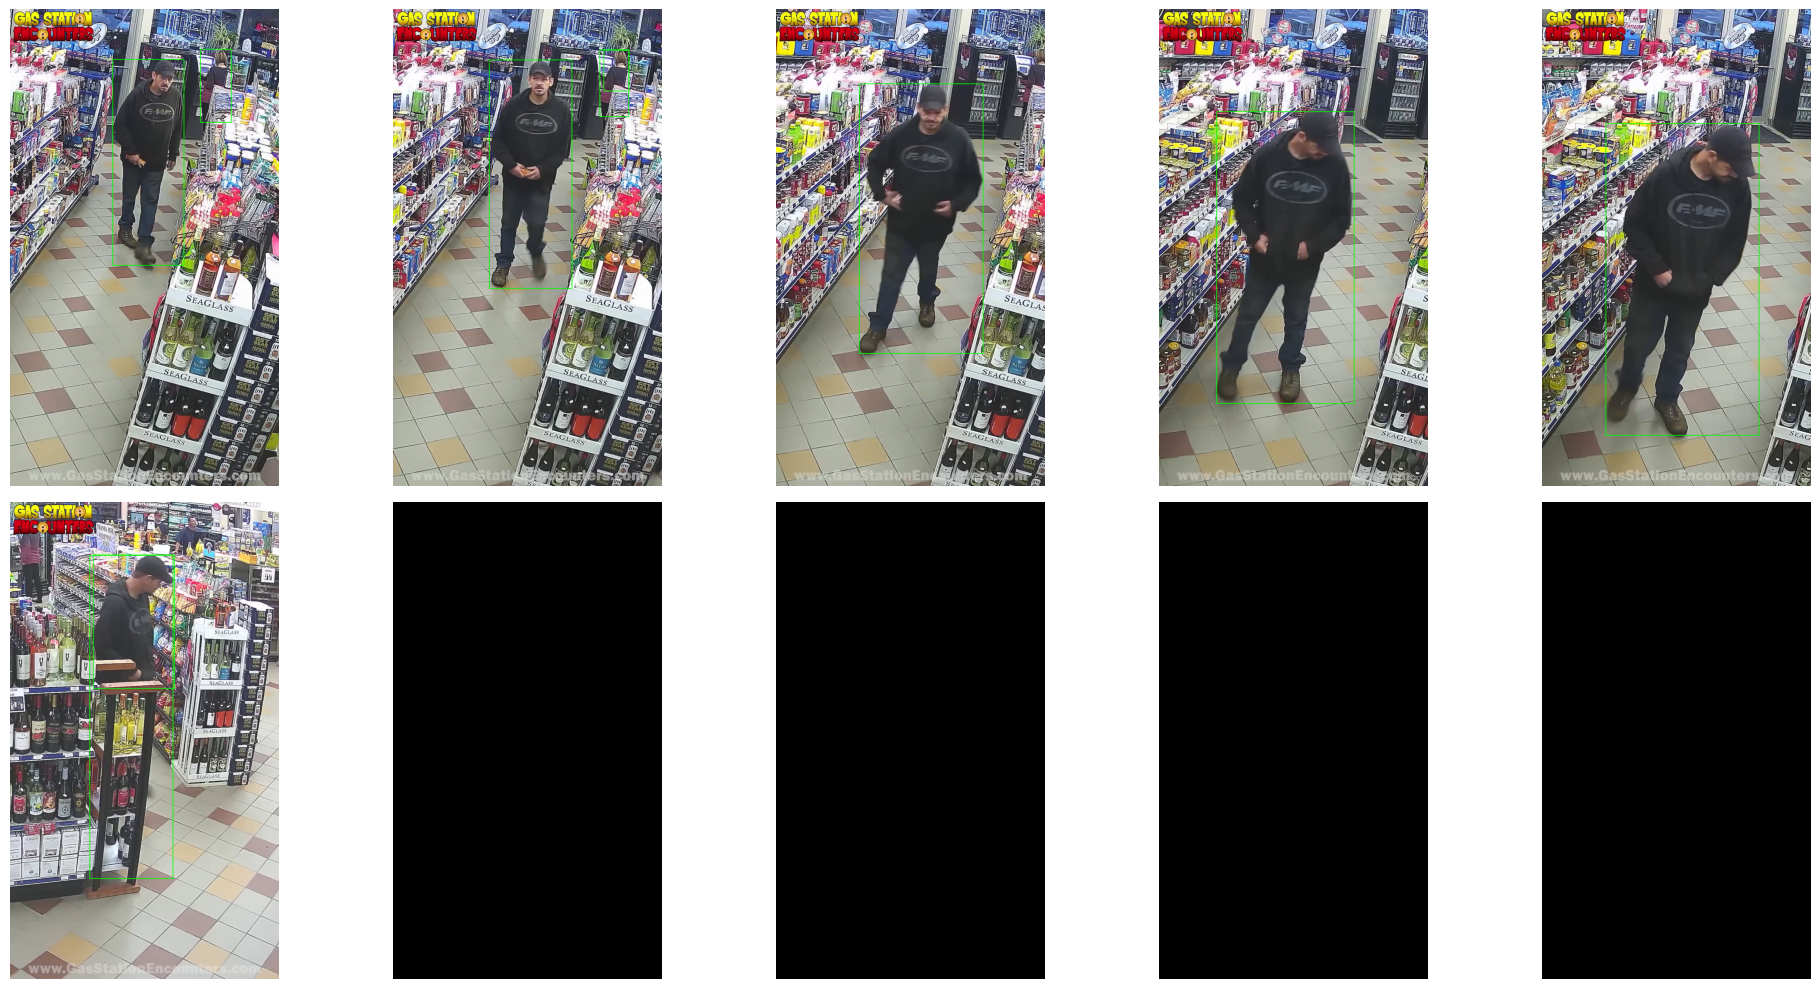


Displaying processed video with person detection:
Buffered data was truncated after reaching the output size limit.

In [ ]:
from IPython.display import Video, display

# Choose a video to predict and visualize
video_path = '/content/shoplifting_Shoplifting_Tag_Team_Caught_Stealing_Crackers_Nutty_Buddies.mp4'

# Get prediction
prediction_label, prediction_prob = predict_video(model, video_path, device)
print(f'Prediction for "{video_path.split("/")[-1]}":')
print(f'\tPredicted Class: {prediction_label} (Confidence: {prediction_prob:.4f})')

# Visualize frames and save the processed video
visualize_frames(video_path)

# Display the processed video in the notebook
print("\nDisplaying processed video with person detection:")
display(Video('output.mp4', embed=True, width=600))

Video saved as 'output.mp4'


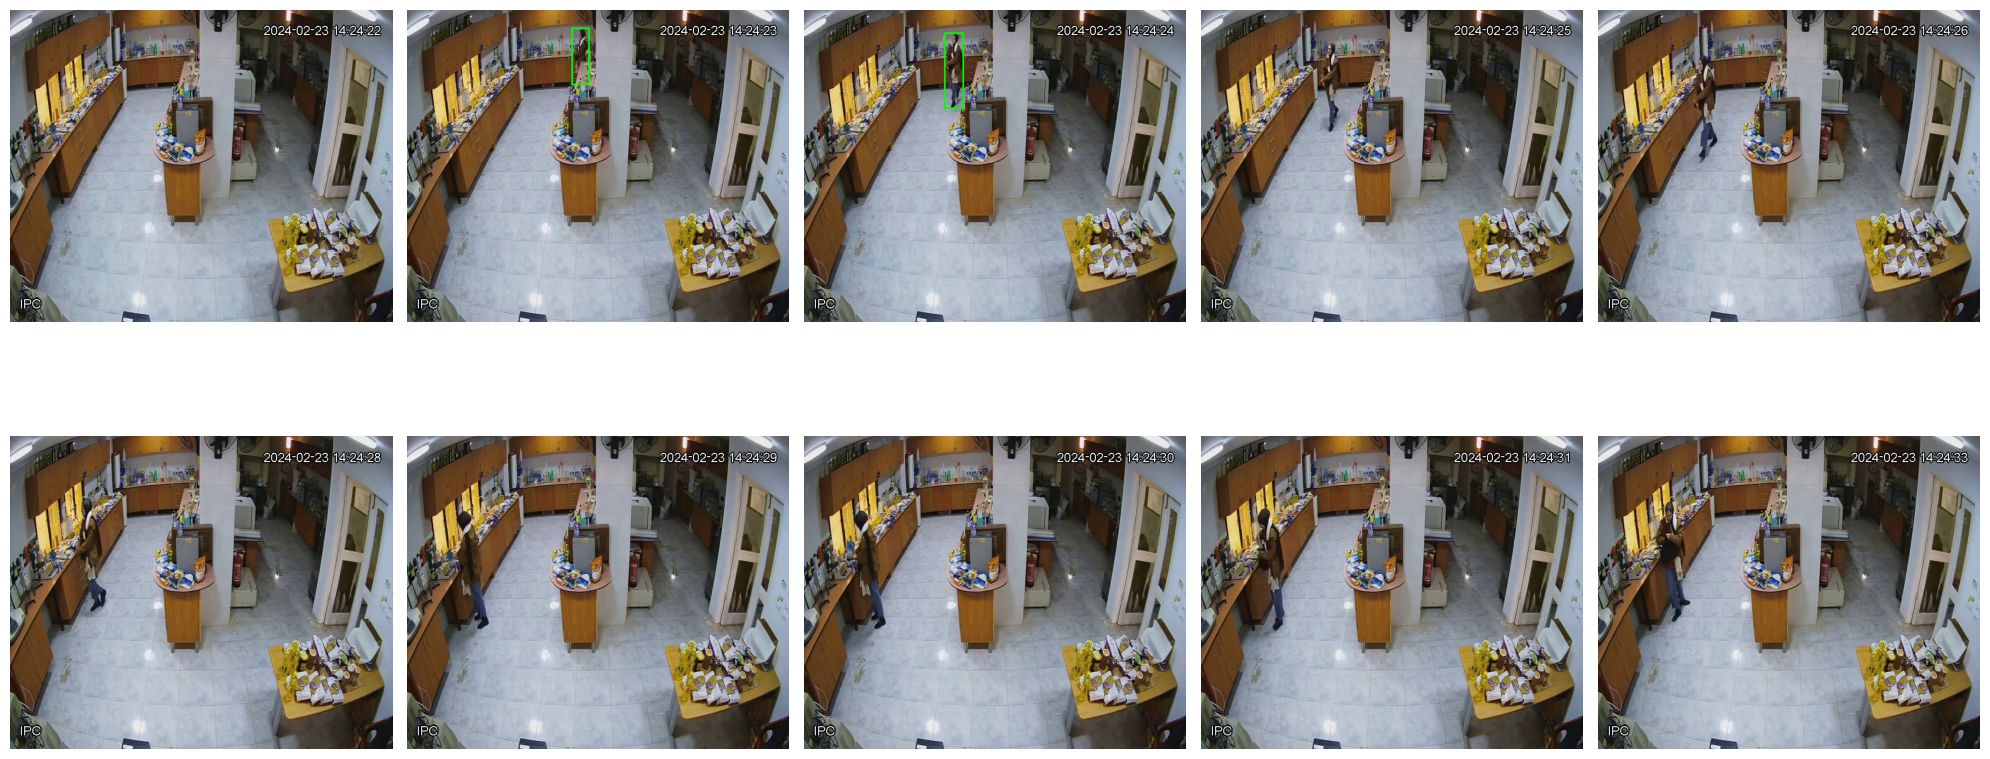

In [ ]:
visualize_frames('/kaggle/input/shop-dataset/Shop DataSet/shop lifters/shop_lifter_36.mp4')

In [ ]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchmetrics.classification import BinaryF1Score, BinaryAccuracy
from itertools import product
from tqdm import tqdm
import json


def train_one_run(
    lr,
    weight_decay,
    patience,
    epochs,
    model_save_path,
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = EfficientNet_Transformer().to(device)

    criterion = nn.BCELoss()
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.1, patience=2)

    f1_metric = BinaryF1Score().to(device)
    acc_metric = BinaryAccuracy().to(device)

    best_val_loss = float("inf")
    no_improve_epochs = 0

    for epoch in range(epochs):
        # ================= TRAIN =================
        model.train()
        f1_metric.reset()
        acc_metric.reset()

        train_loss = 0.0

        for videos, labels in tqdm(train_loader, leave=False):
            videos = videos.to(device)
            labels = labels.to(device)

            optimizer.zero_grad(set_to_none=True)

            logits = model(videos).squeeze(1)
            loss = criterion(logits, labels)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            preds = (torch.sigmoid(logits) > 0.5).int()
            f1_metric.update(preds, labels.int())
            acc_metric.update(preds, labels.int())

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # ================= VALIDATION =================
        model.eval()
        f1_metric.reset()
        acc_metric.reset()

        val_loss = 0.0

        with torch.no_grad():
            for videos, labels in val_loader:
                videos = videos.to(device)
                labels = labels.to(device)

                logits = model(videos).squeeze(1)
                loss = criterion(logits, labels)

                preds = (torch.sigmoid(logits) > 0.5).int()
                f1_metric.update(preds, labels.int())
                acc_metric.update(preds, labels.int())

                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_f1 = f1_metric.compute().item()

        scheduler.step(val_loss)

        print(
            f"LR={lr} WD={weight_decay} | "
            f"Epoch {epoch+1} | Val Loss={val_loss:.4f} | Val F1={val_f1:.4f}"
        )

        # ================= EARLY STOPPING =================
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            no_improve_epochs = 0
            torch.save(model.state_dict(), model_save_path)
        else:
            no_improve_epochs += 1
            if no_improve_epochs >= patience:
                break

    return best_val_loss


# =========================
# HYPERPARAMETER SEARCH
# =========================
search_space = {
    "lr": [1e-4, 3e-4, 1e-3],
    "weight_decay": [1e-4, 1e-5],
    "patience": [3],
}

best_score = float("inf")
best_config = None
best_model_path = "best_model_hparam.pth"

for lr, wd, patience in product(
    search_space["lr"],
    search_space["weight_decay"],
    search_space["patience"],
):
    print(f"\nRunning config: lr={lr}, weight_decay={wd}")

    val_loss = train_one_run(
        lr=lr,
        weight_decay=wd,
        patience=patience,
        epochs=15,
        model_save_path=best_model_path,
    )

    if val_loss < best_score:
        best_score = val_loss
        best_config = {
            "learning_rate": lr,
            "weight_decay": wd,
            "patience": patience,
        }

# Save best hyperparameters
with open("best_hyperparameters.json", "w") as f:
    json.dump(best_config, f, indent=4)

print("\nBest Configuration:")
print(best_config)
print(f"Best model saved at: {best_model_path}")



Running config: lr=0.0001, weight_decay=0.0001


LR=0.0001 WD=0.0001 | Epoch 1 | Val Loss=0.1626 | Val F1=0.5804


LR=0.0001 WD=0.0001 | Epoch 2 | Val Loss=0.1405 | Val F1=0.5804


LR=0.0001 WD=0.0001 | Epoch 3 | Val Loss=0.3143 | Val F1=0.5804
